In [ ]:
from tensorflow.keras import datasets
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[19493 29034 33345 32220 32749 41018 39288 28188]


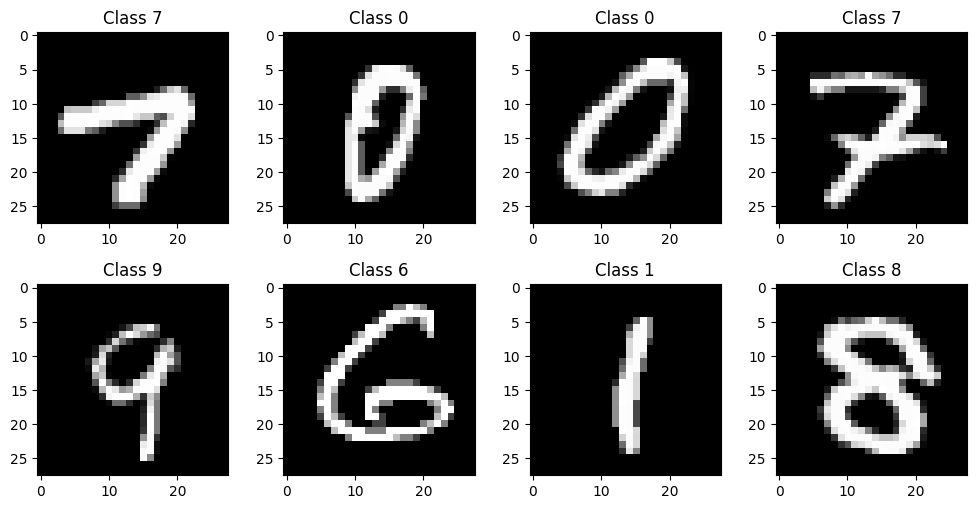

In [ ]:
# show image of training data
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 10)) # set size of figure 10x10
rand_indexes = np.random.randint(0, x_train.shape[0], 8) # select 8 digits(0~9) randomly
print(rand_indexes)

for index,im_index in enumerate(rand_indexes):
    plt.subplot(4, 4, index+1)
    plt.imshow(x_train[im_index], cmap = 'gray', interpolation = 'none')
    plt.title('Class %d' % y_train[im_index])
plt.tight_layout()

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
#img -> rgb 0~255
x_train = x_train/255
x_test = x_test/255

In [ ]:
import numpy as np

In [ ]:
print(np.min(x_train))
print(np.max(x_train))

0.0
1.0


In [ ]:
x_train = x_train.reshape(-1, 28, 28 ,1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
print(x_train.shape)

(60000, 28, 28, 1)


In [ ]:
# data -> 100 7:1:2

"""
What Conv2D expects

Conv2D layers require 4 dimensions:

(batch_size, height, width, channels)

For MNIST this should be:

(60000, 28, 28, 1)
60000 → number of training images
28 → image height
28 → image width
1 → grayscale channel
"""

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    #train 100 -> 70
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#training
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9197 - loss: 0.2666 - val_accuracy: 0.9745 - val_loss: 0.0884
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9709 - loss: 0.0979 - val_accuracy: 0.9799 - val_loss: 0.0656
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9796 - loss: 0.0674 - val_accuracy: 0.9833 - val_loss: 0.0580
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9837 - loss: 0.0517 - val_accuracy: 0.9852 - val_loss: 0.0505
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9865 - loss: 0.0418 - val_accuracy: 0.9852 - val_loss: 0.0530
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9860 - val_loss: 0.0524
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9905 - loss: 0.0293 - val_accuracy: 0.9862 - val_loss: 0.0472
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9912 - loss: 0.0257 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

In [ ]:
print(test_loss)
print(test_acc)

0.04035244882106781
0.9872999787330627


In [ ]:
y_prob = model.predict(x_test[:20], verbose=0)
y_pred = np.argmax(y_prob, axis=1)

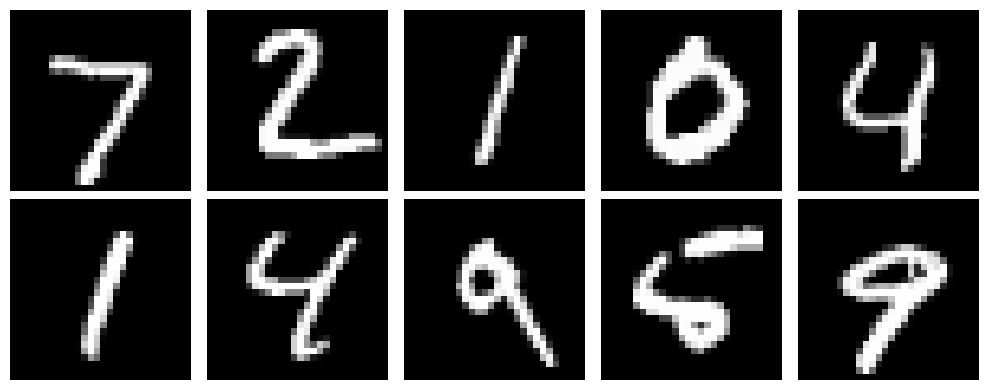

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i].squeeze(), cmap='gray')
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
y_prob = np.round(y_prob,10)
print(y_prob)
print(y_test)

[[0.        0.        0.        0.        0.        0.        0.
  1.        0.        0.       ]
 [0.        0.        1.        0.        0.        0.        0.
  0.        0.        0.       ]
 [0.        1.        0.        0.        0.        0.        0.
  0.        0.        0.       ]
 [1.        0.        0.        0.        0.        0.        0.
  0.        0.        0.       ]
 [0.        0.        0.        0.        1.        0.        0.
  0.        0.        0.       ]
 [0.        1.        0.        0.        0.        0.        0.
  0.        0.        0.       ]
 [0.        0.        0.        0.        1.        0.        0.
  0.        0.        0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.        0.        1.       ]
 [0.        0.        0.        0.        0.        0.9700001 0.03
  0.        0.        0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.        0.        1.       ]
 [1.        0.    

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 975    1    1    1    0    0    2    0    0    0]
 [   0 1133    1    0    0    0    1    0    0    0]
 [   2    4 1014    1    1    0    0    8    1    1]
 [   0    0    1 1000    0    4    0    3    1    1]
 [   0    0    0    0  977    0    1    0    0    4]
 [   1    0    0    8    0  875    6    0    0    2]
 [   5    2    0    0    5    1  945    0    0    0]
 [   1    1    3    0    0    0    0 1021    1    1]
 [   2    2    3    1    1    2    4    3  951    5]
 [   2    0    1    4    9    1    0    8    2  982]]


In [ ]:
print(y_test.shape)

(10000,)


In [ ]:
print(np.bincount(y_test))

[ 980 1135 1032 1010  982  892  958 1028  974 1009]


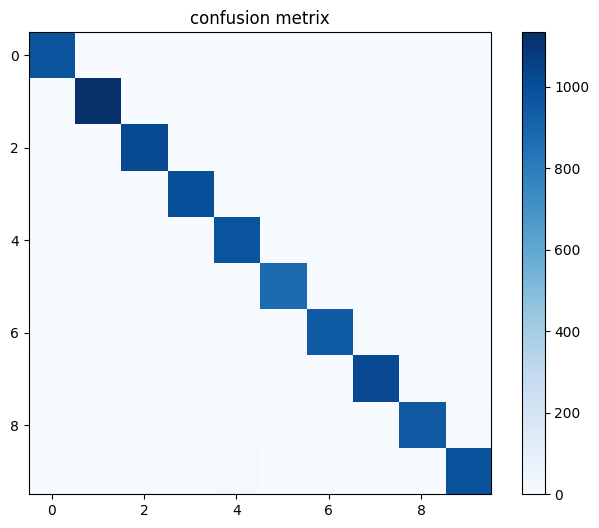

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("confusion metrix")
plt.colorbar()

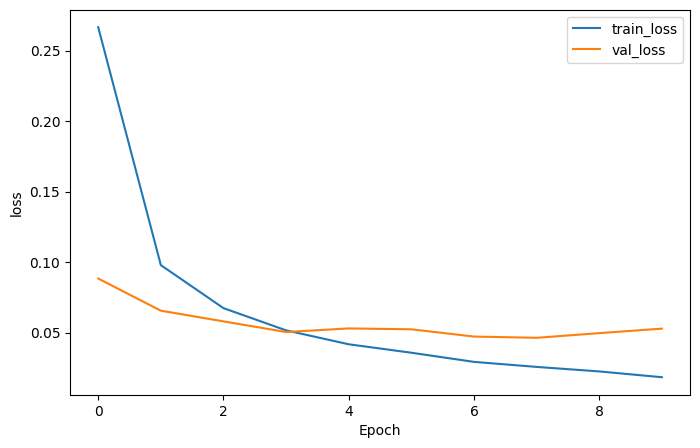

In [ ]:
#loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()